In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
     

In [2]:
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,1.644923,-2.623589,-0.641352,2.673555,0.284512,0
1,1.854765,1.201382,-2.573128,0.288478,-0.942413,0
2,-1.915654,-2.398719,1.434806,2.687325,-0.012037,0
3,0.160568,-1.654176,-0.541601,1.442863,-0.717075,0
4,1.107599,0.180984,3.397899,0.958778,-2.881619,1


In [4]:

# function for row sampling

def sample_rows(df,percent):
  return df.sample(int(percent*df.shape[0]),replace=True)

In [14]:
# function for feature sampling
import random
def sample_features(df,percent):
  cols = random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
  new_df = df[cols]
  new_df['target'] = df['target']
  return new_df

In [15]:

# function for combined sampling

def combined_sampling(df,row_percent,col_percent):
  new_df = sample_rows(df,row_percent)
  return sample_features(new_df,col_percent)

In [16]:
df1 = combined_sampling(df,0.5,0.5)
df2 = combined_sampling(df,0.5,0.5)
df3 = combined_sampling(df,0.5,0.5)

In [17]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col5', 'col1', 'target'], dtype='str')
Index(['col3', 'col4', 'target'], dtype='str')
Index(['col5', 'col1', 'target'], dtype='str')


In [18]:
df3

,col5,col1,target
91,-0.489795,-1.100588,0
68,-0.606533,2.203759,0
59,-1.968526,3.551340,0
50,-0.378508,1.159038,0
63,-2.450639,2.562852,1
6,0.167885,2.363044,0
71,-0.324105,0.474096,1
13,-2.992294,2.837064,0
52,0.054100,2.954855,0
50,-0.378508,1.159038,0


In [19]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()

In [20]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [21]:
from sklearn.tree import plot_tree

[Text(0.6617647058823529, 0.9375, 'x[1] <= 2.204\ngini = 0.493\nsamples = 50\nvalue = [22.0, 28.0]'),
 Text(0.4411764705882353, 0.8125, 'x[0] <= 1.732\ngini = 0.45\nsamples = 41\nvalue = [14.0, 27.0]'),
 Text(0.5514705882352942, 0.875, 'True  '),
 Text(0.29411764705882354, 0.6875, 'x[1] <= -0.073\ngini = 0.401\nsamples = 36\nvalue = [10, 26]'),
 Text(0.17647058823529413, 0.5625, 'x[1] <= -0.397\ngini = 0.444\nsamples = 6\nvalue = [4, 2]'),
 Text(0.11764705882352941, 0.4375, 'x[0] <= -1.786\ngini = 0.444\nsamples = 3\nvalue = [1, 2]'),
 Text(0.058823529411764705, 0.3125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.17647058823529413, 0.3125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.23529411764705882, 0.4375, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.4117647058823529, 0.5625, 'x[0] <= -0.741\ngini = 0.32\nsamples = 30\nvalue = [6, 24]'),
 Text(0.35294117647058826, 0.4375, 'gini = 0.0\nsamples = 12\nvalue = [0, 12]'),
 Text(0.47058823529411764, 0.4375, 'x[0] <=

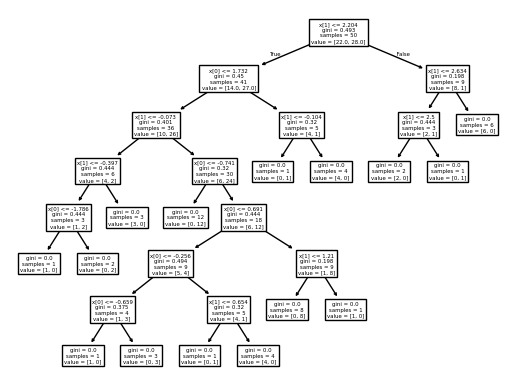

In [22]:
plot_tree(clf1)

[Text(0.5357142857142857, 0.9166666666666666, 'x[0] <= -0.132\ngini = 0.499\nsamples = 50\nvalue = [24, 26]'),
 Text(0.2857142857142857, 0.75, 'x[1] <= 3.103\ngini = 0.227\nsamples = 23\nvalue = [20, 3]'),
 Text(0.4107142857142857, 0.8333333333333333, 'True  '),
 Text(0.14285714285714285, 0.5833333333333334, 'x[0] <= -0.554\ngini = 0.1\nsamples = 19\nvalue = [18, 1]'),
 Text(0.07142857142857142, 0.4166666666666667, 'gini = 0.0\nsamples = 15\nvalue = [15, 0]'),
 Text(0.21428571428571427, 0.4166666666666667, 'x[1] <= 0.604\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.14285714285714285, 0.25, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.2857142857142857, 0.25, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.42857142857142855, 0.5833333333333334, 'x[1] <= 3.379\ngini = 0.5\nsamples = 4\nvalue = [2, 2]'),
 Text(0.35714285714285715, 0.4166666666666667, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.5, 0.4166666666666667, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 T

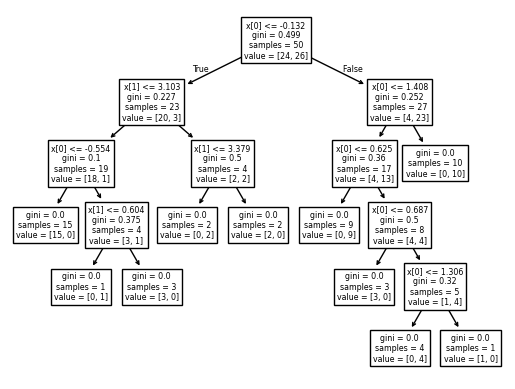

In [23]:
plot_tree(clf2)

[Text(0.5333333333333333, 0.9375, 'x[1] <= 1.133\ngini = 0.449\nsamples = 50\nvalue = [33, 17]'),
 Text(0.3333333333333333, 0.8125, 'x[1] <= -0.73\ngini = 0.455\nsamples = 20\nvalue = [7, 13]'),
 Text(0.43333333333333335, 0.875, 'True  '),
 Text(0.26666666666666666, 0.6875, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.4, 0.6875, 'x[0] <= -0.18\ngini = 0.36\nsamples = 17\nvalue = [4, 13]'),
 Text(0.3333333333333333, 0.5625, 'x[0] <= -1.211\ngini = 0.305\nsamples = 16\nvalue = [3, 13]'),
 Text(0.26666666666666666, 0.4375, 'x[0] <= -1.512\ngini = 0.397\nsamples = 11\nvalue = [3, 8]'),
 Text(0.13333333333333333, 0.3125, 'x[1] <= -0.274\ngini = 0.219\nsamples = 8\nvalue = [1, 7]'),
 Text(0.06666666666666667, 0.1875, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.2, 0.1875, 'gini = 0.0\nsamples = 7\nvalue = [0, 7]'),
 Text(0.4, 0.3125, 'x[1] <= 0.468\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.3333333333333333, 0.1875, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0

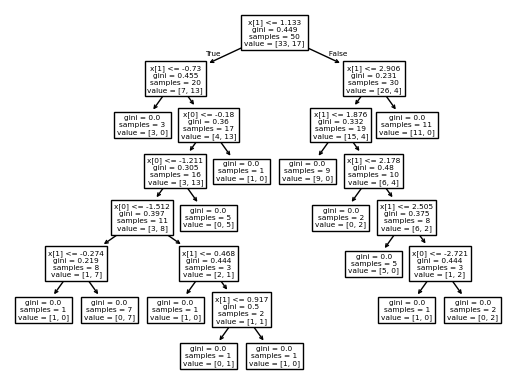

In [24]:
plot_tree(clf3)

In [25]:
clf1.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

c:\Users\Yash\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [26]:
clf2.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

c:\Users\Yash\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])

In [27]:
clf3.predict(np.array([-1.042498,	-0.064323]).reshape(1,2))

c:\Users\Yash\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [28]:
df.sample(14,replace=True)

,col1,col2,col3,col4,col5,target
22,0.848913,1.200622,0.609677,1.729077,-0.600739,1
9,0.011672,1.792924,0.713339,3.104762,0.867739,1
4,1.107599,0.180984,3.397899,0.958778,-2.881619,1
10,-0.004974,1.574607,1.215794,3.343827,-1.745515,1
21,0.135556,1.543517,0.615218,1.596265,1.066222,1
13,2.837064,-0.084242,-1.254857,-0.614043,-2.992294,0
35,1.688566,-1.387892,-0.895115,0.174364,-2.296892,0
72,-0.513538,-2.575111,0.492324,1.642615,-0.717180,0
75,2.255698,-0.237154,3.026694,1.567055,-3.520242,1
54,1.331520,-0.865195,-1.338248,2.615318,1.132956,0
